---
title: "# 组合案例实验：10 只股票的收益与风险 {.unnumbered}"
---

本实验使用 AKShare 获取的腾讯历史行情，读取已经冻结的快照，**执行分析不联网**。固定篮子为事后选定的 10 只股票，仅用于教学，不是历史选股策略、投资建议或全部 A 股的代表样本。

[回到第一讲](../../lectures/intro.qmd#sec-intro-portfolio) · [下载本 Notebook](https://raw.githubusercontent.com/lianxhcn/FinEco/main/notebooks/intro/portfolio-python.ipynb)

任务：用 2018—2023 年训练，2024 年作验证，2025 年作保留测试。比较等权、最小方差与年化预期收益至少 8% 的最小方差组合。验证结果用于报告稳定性，本例不依据验证或测试收益更换规则。

先想清楚我们在比较什么：同一个股票篮子中，只改变配置规则，观察收益与风险怎样变化。这样能把复杂优化与简单等权放在同一条件下比较。时间划分的理由和全部数学符号见[第一讲](../../lectures/intro.qmd#eq-intro-optimization)。第一次运行请按[使用指南](../../getting-started.qmd)取得完整仓库，不能只下载本文件。

本页按“检查数据—估计权重—评价表现—改变一个条件”展开。代码已运行，你可以先看解释和输出，再逐段阅读实现。

## 1. 路径与数据检查

原始获取脚本是 `tools/fetch_intro_prices.py`；它调用 `ak.stock_zh_a_hist_tx(..., adjust="hfq")`。获取与分析分离，避免网络故障改变课堂输出。快照含后复权收盘价，不能直接用作历史实际成交价。

这段代码的任务是确认我们将计算的究竟是哪批记录：

1. 找到含 `RULES.md` 的项目根目录，读取 `prices-long.csv` 和来源清单。
2. 检查“股票代码 + 日期”是否唯一、复权价格是否为正。
3. 把长表转换为“行是日期、列是股票”的价格表，报告每只股票的可用记录和缺失。

输出的缺失交易日数以这份行情表的日期并集为参照，不是另行取得的交易所日历。程序断言失败时应停下来查数据，不能跳过检查直接优化。

In [1]:
from pathlib import Path
import json
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display

# 支持从项目根目录或 Notebook 所在目录运行。
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'RULES.md').exists())
DATA = ROOT/'data/intro'
FIG = ROOT/'figs/raw'
FIG.mkdir(parents=True, exist_ok=True)
STAMP = datetime.now().strftime('%Y%m%d-%H%M%S')
plt.rcParams.update({'font.sans-serif':['Microsoft YaHei','DejaVu Sans'],
                     'axes.unicode_minus':False,'figure.dpi':120})
raw = pd.read_csv(DATA/'prices-long.csv', parse_dates=['date'])
manifest = json.loads((DATA/'source-manifest.json').read_text(encoding='utf-8'))
print('数据来源：', manifest['source'], '；抓取日期：', manifest['retrieved_date'])
assert not raw.duplicated(['symbol','date']).any(), '主键重复'
assert raw['close'].gt(0).all(), '发现非正复权价格'
prices = raw.pivot(index='date', columns='symbol', values='close').sort_index()
names = raw.drop_duplicates('symbol').set_index('symbol')['name']
check = pd.DataFrame({'股票':names, '有效价格数':prices.count(), '缺失交易日数':prices.isna().sum()})
display(check)

数据来源： Tencent Finance via AKShare ；抓取日期： 2026-09-09


,股票,有效价格数,缺失交易日数
symbol,,,
sh600028,中国石化,1942,0
sh600030,中信证券,1925,17
sh600036,招商银行,1942,0
sh600050,中国联通,1942,0
sh600519,贵州茅台,1942,0
sh600900,长江电力,1931,11
sh601398,工商银行,1942,0
sz000333,美的集团,1902,40
sz000651,格力电器,1936,6


阅读检查表后，需要将价格变成可比较的日收益。相邻日期收益是本期价格除以上期价格再减 1；两个价格都有效才可计算。下一段不自动填补缺失，只保留 10 只股票共同有效的收益日期。

这项简化会删除部分日期，因而后面累计的是保留序列的收益，未完整计入被删日期的持有损益。它适合说明配置与评价流程；正式交易回测还需处理停牌估值和可交易性，不能直接沿用。

随后按时间顺序划分样本：前段用于估计参数，2024 年报告验证表现，2025 年保留评价；本例不按后两段的收益修改方案。只用训练期计算均值、标准差和相关性图，避免未来数据进入权重估计。

读输出时看三处：

- **删除数量**：包括第一天没有前一期价格而无法算收益的情况，不能全解释为停牌。
- **训练期均值和波动**：分别由日收益均值乘 252、日标准差乘平方根 252 得到。
- **相关性图**：看对角线之外的股票对，判断风险是否倾向于共同变化。

价格日期数：1942；共同有效收益日期：1857；删除：85
绝对日收益超过 20% 的记录： 0


,股票,训练期年化均值,训练期年化波动
symbol,,,
sh600028,中国石化,5.25%,13.54%
sh600030,中信证券,4.38%,27.78%
sh600036,招商银行,4.58%,26.05%
sh600050,中国联通,1.50%,29.68%
sh600519,贵州茅台,21.39%,28.75%
sh600900,长江电力,10.09%,14.13%
sh601398,工商银行,0.37%,11.77%
sz000333,美的集团,3.52%,29.44%
sz000651,格力电器,-0.81%,24.69%


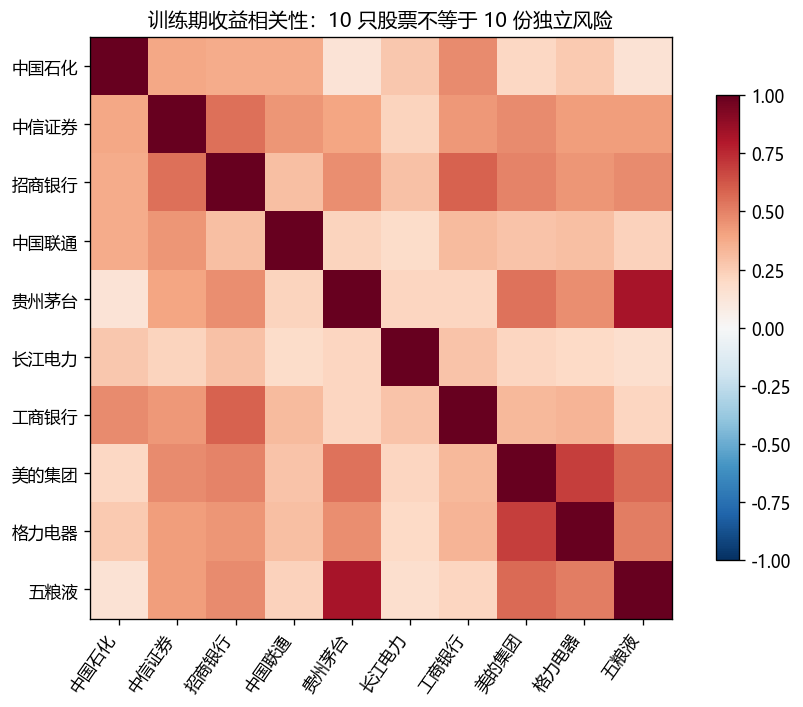

In [2]:
returns_all = prices.pct_change(fill_method=None)
returns = returns_all.dropna(how='any')
print(f'价格日期数：{len(prices)}；共同有效收益日期：{len(returns)}；删除：{len(prices)-len(returns)}')
print('绝对日收益超过 20% 的记录：', int(returns.abs().gt(0.2).sum().sum()))
# 不把真实尾部一律缩尾；异常记录应回查原始价格及权益事件。
train = returns.loc['2018':'2023']
valid = returns.loc['2024']
test = returns.loc['2025']
assert len(train)>1000 and len(valid)>200 and len(test)>200
summary = pd.DataFrame({'股票':names,'训练期年化均值':train.mean()*252,
                        '训练期年化波动':train.std()*np.sqrt(252)})
display(summary.style.format({'训练期年化均值':'{:.2%}','训练期年化波动':'{:.2%}'}))
fig, ax=plt.subplots(figsize=(8,6))
im=ax.imshow(train.corr(),vmin=-1,vmax=1,cmap='RdBu_r')
labels=[names[c] for c in train.columns]
ax.set_xticks(range(10),labels,rotation=55,ha='right'); ax.set_yticks(range(10),labels)
ax.set_title('训练期收益相关性：10 只股票不等于 10 份独立风险')
fig.colorbar(im,ax=ax,shrink=0.8); fig.tight_layout()
fig.savefig(FIG/f'fineco-intro-fig01-correlation-{STAMP}.png'); plt.show()

## 2. 在约束下求权重

共同限制：不卖空、不加杠杆、权重之和为 1、单只股票不超过 20%。8% 是训练期估计均值上的年化算术预期收益约束，不保证未来实现；不可行时程序会明确报告。

算法：先用训练期估计均值与协方差，再解约束优化；随后冻结权重目标。收益估计误差和样本选择问题仍然存在。

代码中的 `mu` 对应正文估计年化均值向量，`cov` 对应估计年化协方差矩阵，`base` 是每只 10% 的等权起点。`bounds` 给每个权重设置 0 到 0.2 的范围，`constraints` 要求权重和为 1；`target=0.08` 时额外要求估计收益达到 8%。`w@cov@w` 与 `w@mu` 分别计算正文的方差和加权均值。

求解器 SLSQP 用于在限制条件下寻找数值解，本讲不要求掌握其算法细节。程序会检查求解状态与约束，失败时报告“目标不可行或优化失败”；求解失败并不单独证明数学问题不可行，还需排查数值条件。

权重表每一列是一种配置。先核对每列合计 100% 和单只上限，再看哪些股票接近边界。某只权重较高，表示它在当前样本估计与约束中被选中，不等于它未来一定表现最好。

In [3]:
n = len(train.columns)
mu = train.mean().to_numpy()*252
cov = train.cov().to_numpy()*252
base = np.repeat(1/n,n)
bounds = [(0,0.2)]*n
constraints = [{'type':'eq','fun':lambda w:w.sum()-1}]
def solve(target=None):
    cons=constraints.copy()
    if target is not None:
        cons.append({'type':'ineq','fun':lambda w:w@mu-target})
    fit=minimize(lambda w:w@cov@w,base,method='SLSQP',bounds=bounds,
                 constraints=cons,options={'ftol':1e-12,'maxiter':1000})
    if not fit.success or abs(fit.x.sum()-1)>1e-6:
        raise ValueError(f'目标不可行或优化失败：{fit.message}')
    assert fit.x.min()>-1e-7 and fit.x.max()<0.200001
    if target is not None: assert fit.x@mu>=target-1e-6
    return fit.x
weights={'等权':base,'最小方差':solve()}
try:
    weights['目标8%']=solve(0.08)
except ValueError as err:
    print(err)
weight_table=pd.DataFrame(weights,index=[names[c] for c in train.columns])
display(weight_table.style.format('{:.2%}'))
print('训练期估计年化收益：', {k:round(float(w@mu),4) for k,w in weights.items()})

,等权,最小方差,目标8%
中国石化,10.00%,20.00%,20.00%
中信证券,10.00%,2.35%,3.24%
招商银行,10.00%,3.26%,2.79%
中国联通,10.00%,8.69%,7.29%
贵州茅台,10.00%,10.30%,20.00%
长江电力,10.00%,20.00%,20.00%
工商银行,10.00%,20.00%,20.00%
美的集团,10.00%,0.00%,0.00%
格力电器,10.00%,15.40%,5.32%
五粮液,10.00%,0.00%,1.36%


训练期估计年化收益： {'等权': 0.0681, '最小方差': 0.056, '目标8%': 0.08}


## 3. 先规定回测规则，再看结果

权重表只是一项配置建议，还不是投资业绩。要模拟持有过程，需要规定何时调整、怎样扣费，以及不同方案是否处在相同条件下。回测是在历史收益上按这些规则计算路径，并不保证当时每笔交易都能执行。

本例统一使用以下规则：

1. **调整时间**：每月首个有效收益日期开始前回到目标权重，月内允许比例漂移。
2. **信息范围**：所有目标权重只由 2018—2023 年估计，验证和测试不重新选权重。
3. **区间起点**：训练、验证和测试各自从 10 万元及目标权重重新开始，互不接续资金。
4. **交易成本**：按买入或卖出金额分别计单边 10 个基点，即 0.1%；1 个基点等于 0.01 个百分点。忽略整数股与滑点，即成交价格偏离设想价格的额外影响。

代码中的双边换手是买入和卖出权重变动绝对值之和。例如，从一只股票转移 10% 的资金到另一只，会同时产生 10% 卖出和 10% 买入，合计 20%。初次满仓买入计一次建仓成本，区间末不假定清仓。

`backtest` 接收日收益表、目标权重和成本率，返回扣费后的日收益与累计换手；`metrics` 将它们转成评价表。净收益计算同时反映扣费后剩余资金与当天涨跌，净值从 1 起按日累计，再乘 10 万元转成金额。Sharpe 与最大回撤定义见[正文指标说明](../../lectures/intro.qmd#eq-intro-performance)。

::: {.callout-tip title="先判断，再看表"}

在同一股票池中，最小方差方案的波动更小，是否就意味着收益也更高？想好理由，再比较下面三种方案。

:::

In [4]:
def backtest(r,w,cost=0.001):
    current=w.copy(); result=[]; turnovers=[]; previous=None
    for date,row in r.iterrows():
        month=(date.year,date.month)
        if previous is None:
            turnover=1.0  # 从现金建立股票头寸。
            current=w.copy()
        elif month!=previous:
            turnover=float(np.abs(w-current).sum()); current=w.copy()
        else:
            turnover=0.0
        gross=float(current@row.to_numpy())
        net=(1-cost*turnover)*(1+gross)-1
        result.append(net); turnovers.append(turnover)
        current=current*(1+row.to_numpy())/(1+gross)
        assert np.isclose(current.sum(),1)
        previous=month
    return pd.Series(result,index=r.index),sum(turnovers)

def metrics(r,turnover):
    wealth=(1+r).cumprod()
    # 纳入期初净值 1，避免遗漏一开仓即下跌形成的回撤。
    peak=wealth.cummax().clip(lower=1)
    rf=(1.02)**(1/252)-1  # 明确的教学无风险利率假设：年有效 2%。
    excess=r-rf
    return {'CAGR':wealth.iloc[-1]**(252/len(r))-1,
            '年化算术均值':r.mean()*252, '年化波动':r.std()*np.sqrt(252),
            'Sharpe':excess.mean()/excess.std()*np.sqrt(252),
            '最大回撤':(1-wealth/peak).max(),'双边换手':turnover,
            '期末金额':100000*wealth.iloc[-1]}
rows=[]; paths={}
for period,r in [('训练',train),('验证',valid),('测试',test)]:
    for name,w in weights.items():
        net,turn=backtest(r,w)
        rows.append({'区间':period,'方案':name,**metrics(net,turn)})
        if period=='测试': paths[name]=net
results=pd.DataFrame(rows)
display(results.style.format({'CAGR':'{:.2%}','年化算术均值':'{:.2%}',
 '年化波动':'{:.2%}','Sharpe':'{:.2f}','最大回撤':'{:.2%}','双边换手':'{:.2f}','期末金额':'{:,.0f}'}))
results.to_csv(DATA/'portfolio-results.csv',index=False,encoding='utf-8-sig')
weight_table.to_csv(DATA/'portfolio-weights.csv',encoding='utf-8-sig')

,区间,方案,CAGR,年化算术均值,年化波动,Sharpe,最大回撤,双边换手,期末金额
0,训练,等权,5.19%,6.42%,16.47%,0.27,31.05%,3.65,"131,709"
1,训练,最小方差,4.64%,5.26%,12.00%,0.27,16.16%,3.02,"128,007"
2,训练,目标8%,7.22%,7.75%,12.42%,0.46,15.77%,3.26,"146,189"
3,验证,等权,23.54%,22.06%,13.63%,1.47,7.28%,1.32,"122,504"
4,验证,最小方差,21.93%,20.45%,11.15%,1.66,6.59%,1.25,"120,972"
5,验证,目标8%,17.73%,17.00%,11.65%,1.29,6.26%,1.29,"116,966"
6,测试,等权,0.27%,0.68%,9.06%,-0.14,5.94%,1.29,"100,257"
7,测试,最小方差,1.03%,1.31%,7.52%,-0.09,4.77%,1.23,"100,994"
8,测试,目标8%,0.49%,0.79%,7.80%,-0.15,4.26%,1.23,"100,472"


结果先看“测试”三行，以相同评价区间比较不同方案：

1. **读收益**：CAGR 按有效日数折成年复合增长率，考虑收益的乘法累计；“年化算术均值”则是日均收益乘 252，两者不必相同。
2. **读风险**：年化波动描述收益分散程度；最大回撤描述这条路径从历史高点的最大跌幅。
3. **读相对表现**：Sharpe 使用年有效无风险利率 2% 的教学假设；它为负不等于累计收益必然为负。

当前输出中，最小方差方案的测试期波动为 7.52%，等权为 9.06%；但三个测试 Sharpe 均为负。这个比较支持“在本例测试期降低了波动”，不足以支持“满足所有投资目标”。“双边换手”是区间累计比例，不是平均每天的比例。

再比较训练与验证的同一指标，观察方案是否稳定。历史表现变化不奇怪，且今天选定的股票篮子仍有样本选择问题。接下来的两张图把表中的净收益展开为金额路径和正的回撤幅度；回撤越高，损失越深，10% 虚线只是情境阈值。

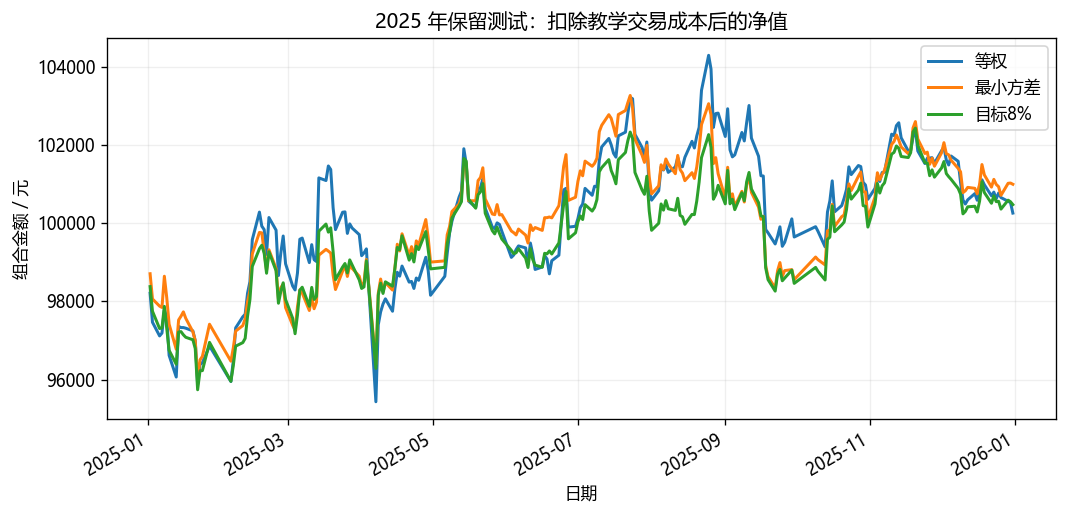

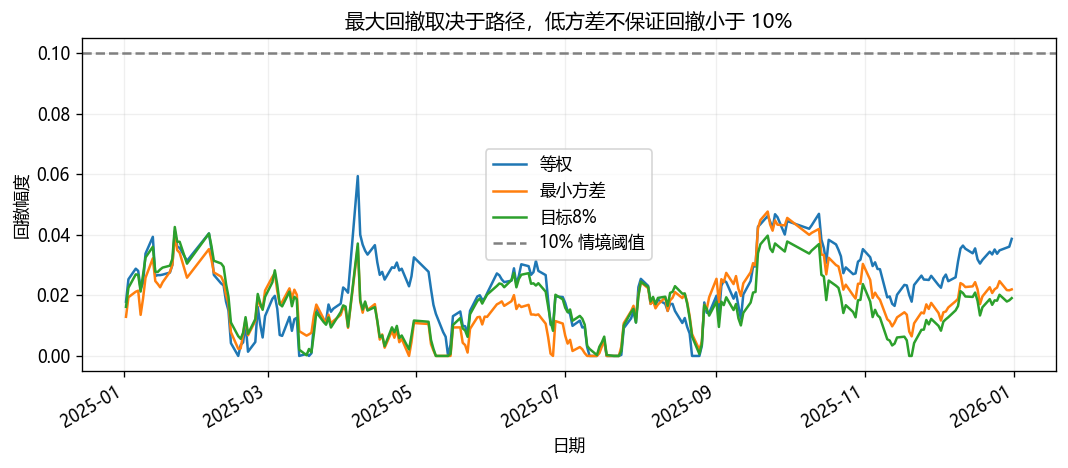

In [5]:
net_returns=pd.DataFrame(paths)
wealth=(1+net_returns).cumprod()
fig,ax=plt.subplots(figsize=(9,4.4))
(wealth*100000).plot(ax=ax,linewidth=1.8)
ax.set_title('2025 年保留测试：扣除教学交易成本后的净值')
ax.set_ylabel('组合金额 / 元'); ax.set_xlabel('日期'); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG/f'fineco-intro-fig02-wealth-{STAMP}.png'); plt.show()
fig,ax=plt.subplots(figsize=(9,4))
(1-wealth/wealth.cummax().clip(lower=1)).plot(ax=ax)
ax.axhline(0.1,color='gray',linestyle='--',label='10% 情境阈值')
ax.set_title('最大回撤取决于路径，低方差不保证回撤小于 10%')
ax.set_ylabel('回撤幅度'); ax.set_xlabel('日期'); ax.legend(); ax.grid(alpha=0.2)
fig.tight_layout(); fig.savefig(FIG/f'fineco-intro-fig03-drawdown-{STAMP}.png'); plt.show()

## 4. 成本敏感性与练习

复杂配置可能依赖交易，因此还要问：结论是否依赖过于便宜的交易假设？下面保持数据、权重和再平衡频率不变，只比较单边成本为零、10 和 30 个基点的情况。分别对应代码中的 0、0.001 和 0.003。

这是一项单条件敏感性分析。先预测同一方案在成本提高后净收益怎样变化，再读表核对；方案间排名未必必然改变。本例目标权重冻结、月度调整，不能把成本影响外推到高频交易。

In [6]:
sensitivity=[]
for fee in [0,0.001,0.003]:
    for name,w in weights.items():
        net,turn=backtest(test,w,fee)
        sensitivity.append({'单边成本':fee,'方案':name,**metrics(net,turn)})
display(pd.DataFrame(sensitivity)[['单边成本','方案','CAGR','Sharpe','最大回撤']].style.format(
    {'单边成本':'{:.2%}','CAGR':'{:.2%}','Sharpe':'{:.2f}','最大回撤':'{:.2%}'}))

,单边成本,方案,CAGR,Sharpe,最大回撤
0,0.00%,等权,0.40%,-0.13,5.94%
1,0.00%,最小方差,1.16%,-0.07,4.76%
2,0.00%,目标8%,0.62%,-0.14,4.16%
3,0.10%,等权,0.27%,-0.14,5.94%
4,0.10%,最小方差,1.03%,-0.09,4.77%
5,0.10%,目标8%,0.49%,-0.15,4.26%
6,0.30%,等权,-0.00%,-0.17,5.95%
7,0.30%,最小方差,0.77%,-0.12,4.78%
8,0.30%,目标8%,0.23%,-0.18,4.45%


::: {.callout-tip title="课后小实验：只改交易成本"}

1. 按[练习副本说明](../../getting-started.qmd#sec-guide-practice)保留基准，另开独立练习项目。
2. 在最后一个成本列表中增加单边 50 个基点，即 `0.005`，其他设置保持一致。
3. 重启内核从头运行，比较同一方案在各成本下的 CAGR、Sharpe 和回撤，保留输出。
4. 用三句话记录：你的预测、观察到的变化、这次比较仍未覆盖的交易限制。

:::

本实验完成了从数据检查到方案评价的闭环。继续扩展前，先说清自己的“好组合”标准，并指出哪一步最可能产生偏差。后续课程再加入滚动估计、波动预测和更严格的交易约束。

数据来源与接口：[AKShare 官方文档](https://akshare.akfamily.xyz/data/stock/stock.html)，查询日期 2026-09-09。[一页研究计划](../../exercises/research-plan.qmd)仍按原作业要求提交。